# 6D Pose Estimation

## Setup
**[BOTH - Training & Testing]**


In [ ]:
# Dataset locale 
# prima di eseguire questo codice -> add input -> linemod (caricare il dataset LINEMOD) 

import os
import sys
import subprocess
from pathlib import Path
import shutil

def setup_kaggle_environment():
    """Setup for Kaggle environment"""
    
    print("🔧 Setting up Kaggle environment...")
    
    # 1. Clone repository if needed 
    os.chdir("/kaggle/working")
    if not os.path.exists("6D-pose-estimation"):
        print("📥 Cloning repository...")
        !git clone -q -b baseline-rgb-geometric-depth https://github.com/luigiaceto/6D-pose-estimation.git
    
    os.chdir("/kaggle/working/6D-pose-estimation")
    sys.path.insert(0, os.getcwd())
    
    # 2. Install critical Python packages
    critical_packages = [
        "numpy-quaternion",
        "ultralytics",
        "pyyaml",
        "tqdm"
    ]
    
    print("📦 Installing critical packages...")
    for pkg in critical_packages:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pkg], 
            capture_output=True
        )
    
    # 3. Check scipy/sklearn versions and fix if needed
    try:
        import scipy
        import sklearn
        
        scipy_ok = scipy.__version__.startswith('1.1')
        sklearn_ok = sklearn.__version__.startswith('1.')
        
        if not (scipy_ok and sklearn_ok):
            print("⚠️ Incompatible scipy/sklearn versions, fixing...")
            subprocess.run([
                sys.executable, "-m", "pip", "install", "-q",
                "--upgrade", "--no-deps",
                "scipy>=1.11.0,<2.0.0",
                "scikit-learn>=1.3.0,<2.0.0"
            ])
            # Reload modules
            import importlib
            importlib.reload(scipy)
            importlib.reload(sklearn)
    except Exception as e:
        print(f"⚠️ Warning scipy/sklearn: {e}")
    
    # 4. Download dataset + Add Input LINEMOD
    SRC = Path("/kaggle/input/linemod/Linemod_preprocessed") 
    DST = Path("/kaggle/working/datasets")   
    if not DST.exists():
        print("📦 Copia dataset in working...")
        shutil.copytree(SRC, DST)
    else:
        print("✅ Dataset già copiato")
    # 5. Final verification
    assert DST.exists(), "❌ Dataset mancante!"

    # 6. Disable wandb
    os.environ["WANDB_MODE"] = "disabled"
    
    print("✅ Setup completed!")
    print(f"📂 Working dir: {os.getcwd()}")
    print(f"🐍 Python path: {sys.path[:2]}")
    
    # Test import
    try:
        from data.CustomDatasetPose import IMG_WIDTH, IMG_HEIGHT
        print(f"✅ CustomDatasetPose OK: {IMG_WIDTH}x{IMG_HEIGHT}")
    except ImportError as e:
        print(f"⚠️ Warning import: {e}")
    
    return True

# Run setup
setup_kaggle_environment()

🔧 Setting up Kaggle environment...
📥 Cloning repository...
📦 Installing critical packages...
📦 Copia dataset in working...


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pydantic')

import torch
import time
from torch.utils.data import DataLoader
import wandb
from pathlib import Path

from data.CustomDatasetPose import IMG_WIDTH, IMG_HEIGHT

from utils.init import set_seed
from utils.init import set_device
from utils.data_exploration import get_camera_intrinsics

set_seed(42)

device = set_device()

dataset_root = Path("/kaggle/working/datasets")

cam_k = get_camera_intrinsics(dataset_root) # ottengo la camera intrinsics una volta per tutte

## Dataset Preprocessing
**[BOTH - Training & Testing]**

Copy ground truth files to ```Linemod_preprocessed```:

In [6]:
from utils.data_exploration import get_class_names
from utils.preprocessing import copy_gt_file, change_02gt, quaternion_gt

folder_names = get_class_names(dataset_root)

In [7]:
copy_gt_file(dataset_root, folder_names)

Change ```02_gt.yml``` to take only one object:

In [8]:
change_02gt(str(dataset_root / "02_gt.yml"))

Add quaternion ground truth to the gt files:

In [9]:
quaternion_gt(dataset_root)

## Data Exploration
**[OPTIONAL - Visualization only]**

Load an image to check if it's all ok:

In [ ]:
from utils.data_exploration import load_image

load_image(dataset_root, label=1, object=0)

## Define the Custom Dataset
**[BOTH - Training & Testing]**

In [10]:
from data.CustomDatasetPose import CustomDatasetPose

do_pose_training = True   # questo decide se eseguire la cella train() oppure no

train_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="train",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)
val_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="validation",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)
test_dataset = CustomDatasetPose(
    dataset_root=dataset_root,
    split="test",
    train_ratio=0.8,
    seed=42,
    cam_K=cam_k
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 12640
Validation samples: 1580
Testing samples: 1580


## Data Preprocessing for YOLO
**[TRAINING ONLY]**

In [ ]:
train_samples = train_dataset.get_samples_id()
validation_samples = val_dataset.get_samples_id()
test_samples = test_dataset.get_samples_id() # test folder is optional for training YOLO

Create a new folder containing all the info for YOLO, we just need the rgb image and a text file with the label and bounding box.
The ```Linemod_preprocessed``` is not removed, as it contains info about translation and rotation that are needed for pose estimation, but not for YOLO object detection model.

Create YOLO yaml:

In [ ]:
from utils.preprocessing import create_YOLO_yaml

number_classes, class_names = create_YOLO_yaml(folder_names)

While creating the folder structure, we have to change the class id by using the index in the array written in the ```data.yaml```:

In [ ]:
# create a dictionary to have easily access to the index. Dato che usiamo un sottoinsieme
# di folder di LineMOD
index_dict = dict()
for index, elem in enumerate(class_names):
    index_dict[int(elem)] = index

Create the folders:

In [ ]:
from utils.preprocessing import create_dataset_YOLO

counter_df = create_dataset_YOLO(number_classes, train_samples, validation_samples, test_samples, index_dict, train_dataset)

Visualize dataset distribution:

In [ ]:
from utils.data_exploration import load_dataset_distribution

load_dataset_distribution(counter_df, index_dict, number_classes)

## Visualize data
**[OPTIONAL - Visualization only]**

Visualize depth image:

In [ ]:
from utils.data_exploration import load_depth_image

folder = "01"
object_name = "0000"

img = load_depth_image(str(dataset_root / "data" / f"{folder}" / "depth" / f"{object_name}.png"))

Plot the patch of first object of the image, it reads from the ground truth file containing also multiple objects in one image:

In [ ]:
from utils.data_exploration import load_depth_patch

load_depth_patch(dataset_root, folder, object_name, img)

Get data loader:

In [ ]:
from data.DataLoaderCollating import rgb_collate_fn

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Training loader: {len(train_loader)}")
print(f"Validation loader: {len(val_loader)}")
print(f"Test loader: {len(test_loader)}")

Plot one batch of data:

In [ ]:
from utils.data_exploration import plot_batch_data

plot_batch_data(train_loader, val_loader, test_loader)

## YOLO

In [ ]:
IMG_SIZE = 640

**[TRAINING ONLY]**

In [ ]:
from yolo_train import train_YOLO

epochs = 20
batch_size = 64

train_YOLO(epochs, batch_size, IMG_SIZE, device) # train model and save weights to checkpoints/

Validate model on test set:

In [ ]:
from yolo_evaluate import evaluate_YOLO

evaluate_YOLO(epochs, batch_size, IMG_SIZE, device)

Visualize YOLO predictions with bounding boxes:

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Load best model
model = YOLO(str(Path("checkpoints") / "best.pt"))

# Get some test images
yolo_path = Path("datasets") / "linemod" / "YOLO" / "datasets"
test_images_dir = yolo_path / "test" / "images"
test_labels_dir = yolo_path / "test" / "labels"

test_images = [str(test_images_dir / img) for img in os.listdir(str(test_images_dir))[:1]]  # First 5 images

def draw_box(img, box, color, label, thickness=3):
    """Draw bounding box on image"""
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

def yolo_to_xyxy(yolo_box, img_width, img_height):
    """Convert YOLO format (x_center, y_center, width, height) to (x1, y1, x2, y2)"""
    x_center, y_center, width, height = yolo_box
    x1 = (x_center - width/2) * img_width
    y1 = (y_center - height/2) * img_height
    x2 = (x_center + width/2) * img_width
    y2 = (y_center + height/2) * img_height
    return [x1, y1, x2, y2]

# Run inference and visualize
for img_path in test_images:
    # Load image
    img = cv2.imread(img_path)
    img_height, img_width = img.shape[:2]

    # Run YOLO prediction
    results = model.predict(img_path, imgsz=IMG_SIZE, conf=0.5, verbose=False)

    # Draw predictions (BLUE)
    for box in results[0].boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        cls = int(box.cls)
        conf = box.conf.item()
        label = f"Pred: Class {cls} ({conf:.2f})"
        img = draw_box(img, xyxy, (255, 0, 0), label)  # Blue for predictions

    # Load and draw ground truth (GREEN)
    label_file = os.path.join(str(test_labels_dir), os.path.basename(img_path).replace('.png', '.txt').replace('.jpg', '.txt'))
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_gt = int(parts[0])
                    yolo_box = [float(x) for x in parts[1:5]]
                    xyxy_gt = yolo_to_xyxy(yolo_box, img_width, img_height)
                    label_gt = f"GT: Class {cls_gt}"
                    img = draw_box(img, xyxy_gt, (0, 255, 0), label_gt, thickness=2)  # Green for GT

    # Display
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison - {os.path.basename(img_path)}\n Green = Ground Truth | Blue = Prediction")
    plt.axis('off')
    plt.show()

    print(f"\n{os.path.basename(img_path)}:")
    print(f"  Predictions: {len(results[0].boxes)} boxes detected")

## 6D Pose Estimation (Baseline)

### Setup Model and Configuration
**[TRAINING & TESTING]**

In [11]:
# Configuration
config = {
    "batch_size": 32,
    "num_epochs": 50,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "freeze_epochs": 0
}

print(f"Using device: {device}")
print(f"Configuration: {config}")

Using device: cuda
Configuration: {'batch_size': 32, 'num_epochs': 50, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'freeze_epochs': 0}


### Training 6D Pose Model
**[TRAINING ONLY]**

In [ ]:
from baseline_train import train
from data.DataLoaderCollating import rgb_collate_fn

model=None
if do_pose_training:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    model= train(
        train_dataset=train_dataset,
        train_loader=train_loader,
        val_loader=val_loader,
        cam_k=cam_k,
        checkpoint_dir="checkpoints",
        epochs=config["num_epochs"],
        lr=config["learning_rate"],
        weight_dacay=config["weight_decay"],
        device=device,
        freeze_epochs=config["freeze_epochs"]
    )

    print("\nTraining complete! Model saved to checkpoints/best_pose_model.pt")
else:
    print("Skipping pose training")

In [12]:
import shutil
import os

# Crea cartella output pulita
output_dir = "/kaggle/working/model_checkpoint"
os.makedirs(output_dir, exist_ok=True)

# Copia solo il best model
source = "/kaggle/working/6D-pose-estimation/checkpoints/best_pose_model.pt"
dest = os.path.join(output_dir, "best_model.pt")

if os.path.exists(source):
    shutil.copy(source, dest)
    size = os.path.getsize(dest) / (1024 * 1024)
    
    print(f"✅ Best model saved!")
    print(f"   Location: {dest}")
    print(f"   Size: {size:.2f} MB")
    print(f"\n📥 Download from Output tab: model_checkpoint/best_pose_model.pt")
else:
    print(f"❌ Best model not found at: {source}")

✅ Best model saved!
   Location: /kaggle/working/model_checkpoint/best_model.pt
   Size: 296.55 MB

📥 Download from Output tab: model_checkpoint/best_pose_model.pt


### Evaluation 6D Pose Model
**[TESTING ONLY]**

In [12]:
from baseline_evaluate import evaluate
import pandas as pd #evaluate restituisce un dataframe
from pathlib import Path

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
dataset_root = Path("/kaggle") / "working"/ "datasets"
# Evaluate the model on test set
# Shows: ADD accuracy, rotation error, translation error, per-object breakdown
evaluate(
    dataset_root,
    test_dataset=test_dataset,
    test_loader=test_loader,
    cam_k=cam_k,
    checkpoint_path= Path("/kaggle/input/checkpoint") / "best_model.pt",
    device=device,
    save_table= False,
    table_path= str( "./evaluation_results.csv")
)

Evaluating...


100%|██████████| 50/50 [00:21<00:00,  2.30it/s]

Performance Level: POOR



,Object Name,#Samples,Accuracy @10% (%),Rotation Error (deg),Translation Error (cm),ADD / ADD-S (cm),ADD (rot only) (cm)
0,phone,124,11.29,6.87,18.100000,18.180000,1.19
1,camera,120,1.67,6.25,11.290000,11.360000,0.95
2,iron,115,4.35,6.53,18.260000,18.320000,1.39
3,eggbox,126,7.94,7.93,10.730000,8.500000,0.95
4,driller,119,1.68,6.64,13.330000,13.430000,1.45
5,holepuncher,123,1.63,8.97,15.760000,15.890000,1.05
6,glue,122,18.03,5.96,21.200001,17.740000,0.72
7,ape,123,0.81,9.60,12.880000,12.970000,0.91
8,duck,126,1.59,7.12,8.030000,8.070000,0.76
9,lamp,123,4.07,7.76,19.170000,19.290001,1.64


### Visualize 6D Pose Predictions
**[VISUALIZATION ONLY]**

In [13]:
from pathlib import Path
import torch
src = Path("/kaggle/input/checkpoint") / "best_model.pt"
dst = Path("/kaggle/working/model_checkpoint") / "best_model_with_stats.pt"

ckpt = torch.load(src, map_location="cpu", weights_only=False)

ckpt.setdefault("image_mean", [0.485, 0.456, 0.406])
ckpt.setdefault("image_std",  [0.229, 0.224, 0.225])

torch.save(ckpt, dst)
print("Saved:", dst)

Saved: /kaggle/working/model_checkpoint/best_model_with_stats.pt


In [14]:
import numpy as np

class CamKCompat:
    def __init__(self, cam_k):
        cam_k = np.asarray(cam_k).astype(np.float32).reshape(-1)
        assert cam_k.size == 9, f"cam_k deve avere 9 elementi, trovato {cam_k.size}"
        self.flat = cam_k
        self.mat = cam_k.reshape(3, 3)

    def __getitem__(self, key):
        if isinstance(key, tuple):
            i, j = key
            return self.mat[i, j]
        return self.flat[key]

cam_k_vis = CamKCompat(cam_k)


VISUALIZATION: 0060.png

 Object 2 (Class 1)

 GROUND TRUTH:
     Translation: [ 0.1577, -0.0479,  1.0346] m
     Quaternion:  [-0.4077, -0.7712, -0.3450,  0.3464]

 PREDICTION:
     Translation: [ 0.1957, -0.0433,  1.1518] m
     Quaternion:  [ 0.1267, -0.9757, -0.0422,  0.1739]

 ERRORS:
     BBox IoU (2D):        95.20%  ← YOLO detection accuracy
     Translation Error:    12.33 cm
       - X error:   3.80 cm
       - Y error:   0.46 cm
       - Z error (depth):  11.72 cm  ← Main issue!
     Rotation Error:       78.29°




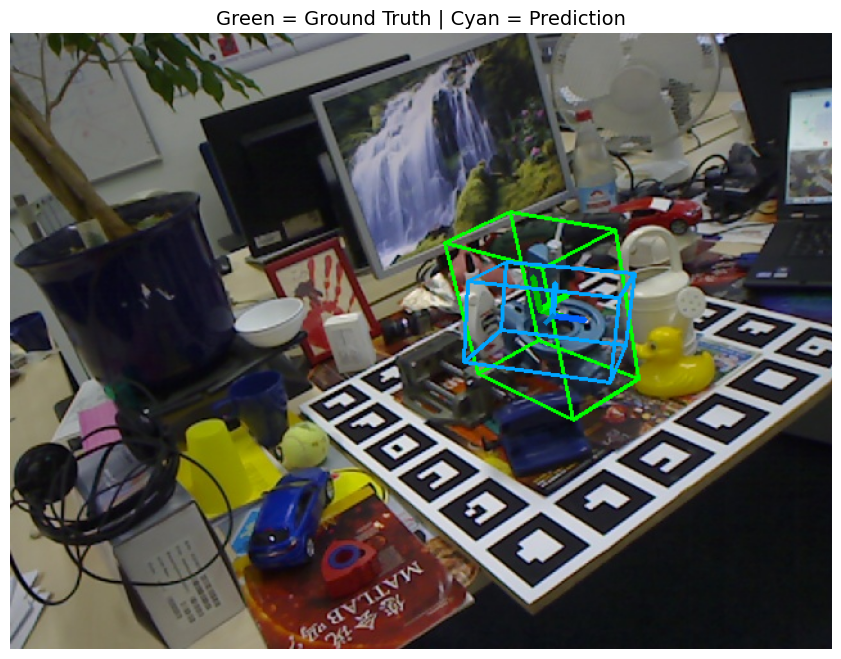

In [24]:
import importlib, visualize
importlib.reload(visualize)
from visualize import visualize_predictions

visualize_predictions(
    dataset_root,
    cam_k=cam_k_vis,
    image_path=str(dataset_root / "data" / "02" / "rgb" / "0060.png"),
    pose_checkpoint=str(Path("/kaggle/working/model_checkpoint") / "best_model_with_stats.pt"),
    device=device
)

### Testing YOLO + ResNet Pipeline